In [57]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
filename = r"C:\Users\gayat\Downloads\09_Call_Volume_Trend_Analysis\og_Call_Volume_Trend_Analysis_Project_9.xlsx"
df = pd.read_excel(filename)
df.head(50)

,Agent_Name,Agent_ID,Customer_Phone_No,Queue_Time(Secs),Date_&_Time,Time,Time_Bucket,Duration(hh:mm:ss),Call_Seconds (s),Call_Status,Wrapped _By,Ringing,IVR _Duration
0,Executives 42,1000042.0,98502XXXXX,2,2022-01-01 09:02:38,9,9_10,0.001111,96,answered,Agent,YES,0.000185
1,Executives 4,1000004.0,80595XXXXX,0,2022-01-01 09:02:40,9,9_10,0.001620,140,answered,Agent,YES,0.000301
2,Executives 65,1000065.0,70202XXXXX,0,2022-01-01 09:02:49,9,9_10,0.000984,85,answered,AutoWrapped,YES,0.000185
3,Executives 55,1000055.0,96104XXXXX,1,2022-01-01 09:02:51,9,9_10,0.001053,91,answered,Agent,YES,0.000289
4,Executives 21,1000021.0,82001XXXXX,0,2022-01-01 09:02:55,9,9_10,0.001910,165,answered,Agent,YES,0.000266
5,NaN,NaN,96424XXXXX,13,2022-01-01 09:04:19,9,9_10,0.000000,0,abandon,NaN,YES,0.000185
6,Executives 55,1000055.0,96737XXXXX,79,2022-01-01 09:04:23,9,9_10,0.000984,85,answered,AutoWrapped,YES,0.000150
7,NaN,NaN,96392XXXXX,60,2022-01-01 09:04:43,9,9_10,0.000000,0,abandon,NaN,YES,0.000197
8,Executives 42,1000042.0,90820XXXXX,52,2022-01-01 09:04:54,9,9_10,0.000752,65,answered,Agent,YES,0.000231
9,Executives 65,1000065.0,97410XXXXX,62,2022-01-01 09:04:54,9,9_10,0.002083,180,answered,AutoWrapped,YES,0.000509


## DATA PREPROCESSING AND OUTLIERS HANDLING

In [60]:
df.rename(columns={'Call_Seconds (s)': 'Call_Seconds(secs)', 'Wrapped _By': 'Wrapped_By','IVR _Duration':'IVR_Duration'}, inplace=True)

In [61]:
print(df.shape)
df_cleaned = df.drop_duplicates()
print('After removing duplicates:', df_cleaned.shape)

(117988, 13)
After removing duplicates: (117988, 13)


In [62]:
# print(df.shape)
# df_cleaned = df.dropna()
# print('After dropping nan values:', df_cleaned.shape)
# df_cleaned = df_cleaned.drop_duplicates()
# print('After removing duplicates:', df_cleaned.shape)

In [63]:
# Check for missing vals
missing_values = df_cleaned.isnull().sum()

# Display cols with missing vals
missing_columns = missing_values[missing_values > 0]
print("Columns with missing values:\n", missing_columns)

Columns with missing values:
 Agent_Name    34198
Agent_ID      34198
Wrapped_By    47877
dtype: int64


In [64]:
# Fill NaN values with a placeholder val
df_cleaned['Agent_Name'].fillna('Unassigned', inplace=True)
df_cleaned['Agent_ID'].fillna('Unassigned', inplace=True)#1000042/NA
df_cleaned['Wrapped_By'].fillna('Unassigned', inplace=True)
# df_cleaned.head(20)

C:\Users\gayat\AppData\Local\Temp\ipykernel_3532\4078891314.py:3: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Unassigned' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [65]:
df_cleaned.head(50)

,Agent_Name,Agent_ID,Customer_Phone_No,Queue_Time(Secs),Date_&_Time,Time,Time_Bucket,Duration(hh:mm:ss),Call_Seconds(secs),Call_Status,Wrapped_By,Ringing,IVR_Duration
0,Executives 42,1000042.0,98502XXXXX,2,2022-01-01 09:02:38,9,9_10,0.001111,96,answered,Agent,YES,0.000185
1,Executives 4,1000004.0,80595XXXXX,0,2022-01-01 09:02:40,9,9_10,0.001620,140,answered,Agent,YES,0.000301
2,Executives 65,1000065.0,70202XXXXX,0,2022-01-01 09:02:49,9,9_10,0.000984,85,answered,AutoWrapped,YES,0.000185
3,Executives 55,1000055.0,96104XXXXX,1,2022-01-01 09:02:51,9,9_10,0.001053,91,answered,Agent,YES,0.000289
4,Executives 21,1000021.0,82001XXXXX,0,2022-01-01 09:02:55,9,9_10,0.001910,165,answered,Agent,YES,0.000266
5,Unassigned,Unassigned,96424XXXXX,13,2022-01-01 09:04:19,9,9_10,0.000000,0,abandon,Unassigned,YES,0.000185
6,Executives 55,1000055.0,96737XXXXX,79,2022-01-01 09:04:23,9,9_10,0.000984,85,answered,AutoWrapped,YES,0.000150
7,Unassigned,Unassigned,96392XXXXX,60,2022-01-01 09:04:43,9,9_10,0.000000,0,abandon,Unassigned,YES,0.000197
8,Executives 42,1000042.0,90820XXXXX,52,2022-01-01 09:04:54,9,9_10,0.000752,65,answered,Agent,YES,0.000231
9,Executives 65,1000065.0,97410XXXXX,62,2022-01-01 09:04:54,9,9_10,0.002083,180,answered,AutoWrapped,YES,0.000509


In [66]:
df.columns

Index(['Agent_Name', 'Agent_ID', 'Customer_Phone_No', 'Queue_Time(Secs)',
       'Date_&_Time', 'Time', 'Time_Bucket', 'Duration(hh:mm:ss)',
       'Call_Seconds(secs)', 'Call_Status', 'Wrapped_By', 'Ringing',
       'IVR_Duration'],
      dtype='object')

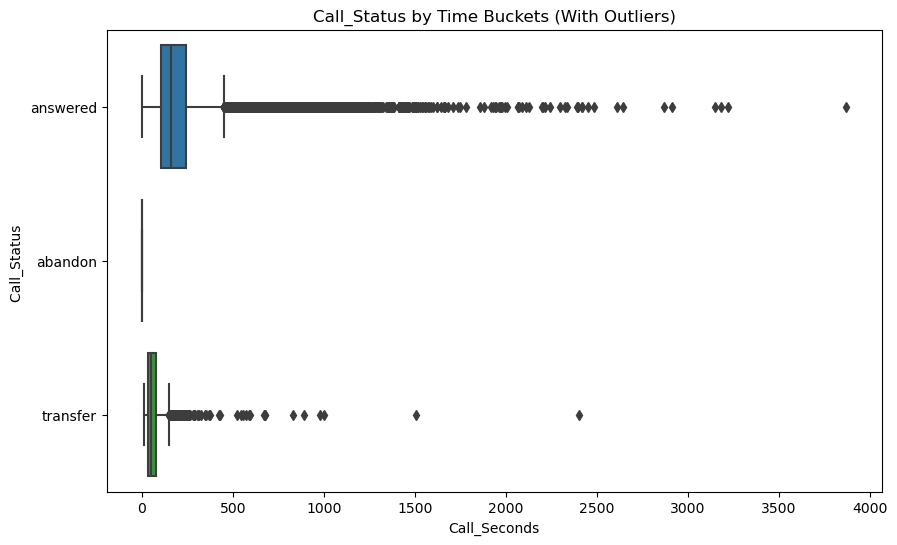

In [67]:
#Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='Call_Seconds(secs)', y='Call_Status', data=df_cleaned)
plt.title('Call_Status by Time Buckets (With Outliers)')
plt.xlabel('Call_Seconds')
plt.ylabel('Call_Status ')
plt.show()

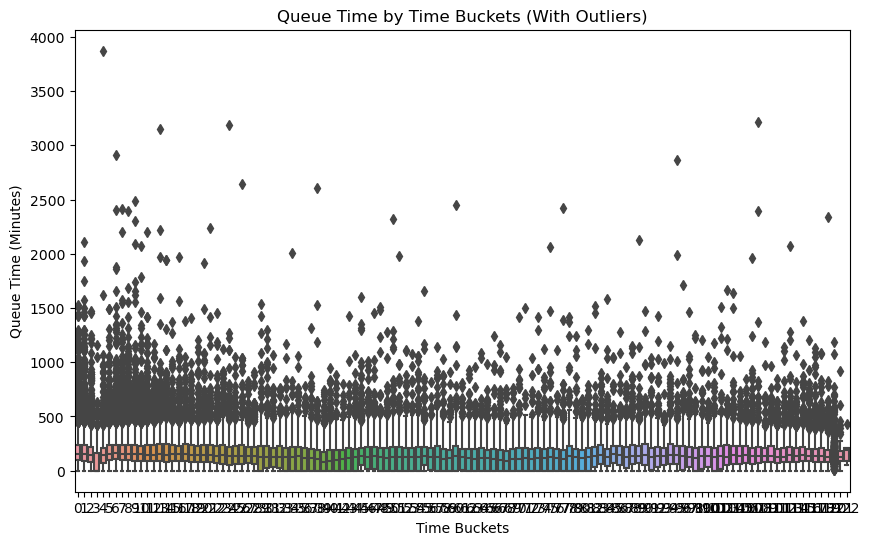

In [68]:
#Outliers 2
plt.figure(figsize=(10, 6))
sns.boxplot(x='Queue_Time(Secs)', y='Call_Seconds(secs)', data=df_cleaned)
plt.title('Queue Time by Time Buckets (With Outliers)')
plt.xlabel('Time Buckets')
plt.ylabel('Queue Time (Minutes)')
plt.show()

~ Decided not to emove Outliers

In [70]:
# # Step 3: Outlier Detection (using IQR method)
# # For numerical columns, calculate IQR and remove outliers

# numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
# Q1 = df_cleaned[numeric_cols].quantile(0.25)
# Q3 = df_cleaned[numeric_cols].quantile(0.75)
# IQR = Q3 - Q1

# # Define outliers as points outside of 1.5 * IQR from Q1 and Q3
# df_cleaned = df_cleaned[~((df_cleaned[numeric_cols] < (Q1 - 1.5 * IQR)) | (df_cleaned[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [71]:
df_cleaned

,Agent_Name,Agent_ID,Customer_Phone_No,Queue_Time(Secs),Date_&_Time,Time,Time_Bucket,Duration(hh:mm:ss),Call_Seconds(secs),Call_Status,Wrapped_By,Ringing,IVR_Duration
0,Executives 42,1000042.0,98502XXXXX,2,2022-01-01 09:02:38,9,9_10,0.001111,96,answered,Agent,YES,0.000185
1,Executives 4,1000004.0,80595XXXXX,0,2022-01-01 09:02:40,9,9_10,0.001620,140,answered,Agent,YES,0.000301
2,Executives 65,1000065.0,70202XXXXX,0,2022-01-01 09:02:49,9,9_10,0.000984,85,answered,AutoWrapped,YES,0.000185
3,Executives 55,1000055.0,96104XXXXX,1,2022-01-01 09:02:51,9,9_10,0.001053,91,answered,Agent,YES,0.000289
4,Executives 21,1000021.0,82001XXXXX,0,2022-01-01 09:02:55,9,9_10,0.001910,165,answered,Agent,YES,0.000266
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117983,Executives 7,1000007.0,85399XXXXX,62,2022-01-23 20:57:58,20,20_21,0.001065,92,answered,Agent,YES,0.000486
117984,Executives 36,1000036.0,88397XXXXX,22,2022-01-23 20:58:24,20,20_21,0.000856,74,answered,Agent,YES,0.000174
117985,Executives 48,1000048.0,70035XXXXX,14,2022-01-23 20:58:34,20,20_21,0.001250,108,answered,Agent,YES,0.000266
117986,Executives 33,1000033.0,87773XXXXX,26,2022-01-23 20:58:53,20,20_21,0.000845,73,answered,Agent,YES,0.000752


In [72]:
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Call_Seconds(secs)', y='Call_Status', data=df_cleaned)
# plt.title('Call_Status by Time Buckets (Without Outliers)')
# plt.xlabel('Call_Seconds')
# plt.ylabel('Call_Status ')
# plt.show()

In [73]:
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Queue_Time(Secs)', y='Call_Seconds(secs)', data=df_cleaned)
# plt.title('Queue Time by Time Buckets (Without Outliers)')
# plt.xlabel('Time Buckets')
# plt.ylabel('Queue Time (Minutes)')
# plt.show()

In [74]:
df_cleaned.shape

(117988, 13)

In [75]:
df_cleaned.to_excel('Call_Volume_Trend_Analysis_Project_8_preprocessed.xlsx')# Saved Preprocessed data

### DATA ANALYTICS TASKS

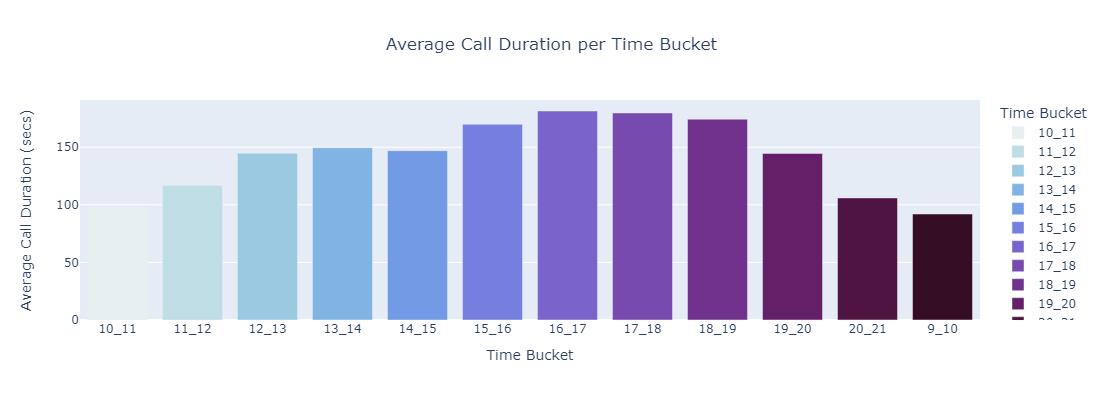

In [77]:
#1. Average Call Duration

# Calculate the average call duration per time bucket
average_duration = df_cleaned.groupby('Time_Bucket')['Call_Seconds(secs)'].mean().reset_index()

# Visualize the average call duration
fig1 = px.bar(average_duration, x='Time_Bucket', y='Call_Seconds(secs)',
             labels={'Call_Seconds(secs)': 'Average Call Duration (secs)', 'Time_Bucket': 'Time Bucket'},
             title='Average Call Duration per Time Bucket',
            color='Time_Bucket',
             color_discrete_sequence=px.colors.sequential.dense)
# Update the layout to reduce width
fig1.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket")
)
fig1.show()

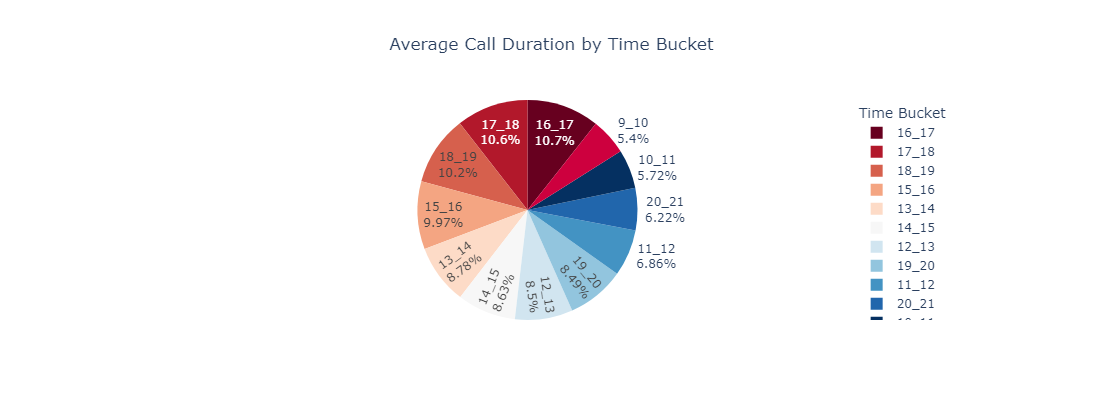

In [78]:

# Grouping by Time Bucket and calculating average call duration
avg_duration = df_cleaned.groupby('Time_Bucket')['Call_Seconds(secs)'].mean().reset_index()

# Creating a pie chart
fig2 = px.pie(avg_duration, values='Call_Seconds(secs)', names='Time_Bucket', 
             title='Average Call Duration by Time Bucket',
             color_discrete_sequence=px.colors.sequential.RdBu)
fig2.update_traces(textinfo='percent+label')
fig2.update_layout(
    width=400,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket"))
fig2.show()

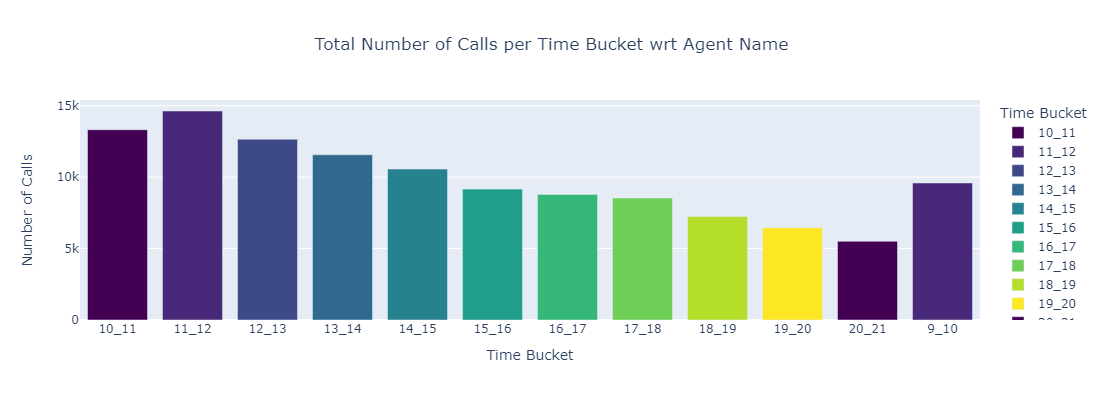

In [79]:
#2. Call Volume Analysis

# Count the number of calls in each time bucket
call_volume = df_cleaned.groupby('Time_Bucket')['Agent_Name'].count().reset_index()
call_volume.rename(columns={'Agent_Name': 'Number of Calls'}, inplace=True)

# Visualize the call volume
fig3 = px.bar(call_volume, x='Time_Bucket', y='Number of Calls',
             labels={'Number of Calls': 'Number of Calls', 'Time_Bucket': 'Time Bucket'},
             title='Total Number of Calls per Time Bucket wrt Agent Name',
            color='Time_Bucket',
             color_discrete_sequence=px.colors.sequential.Viridis)

fig3.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket")
)
fig3.show()

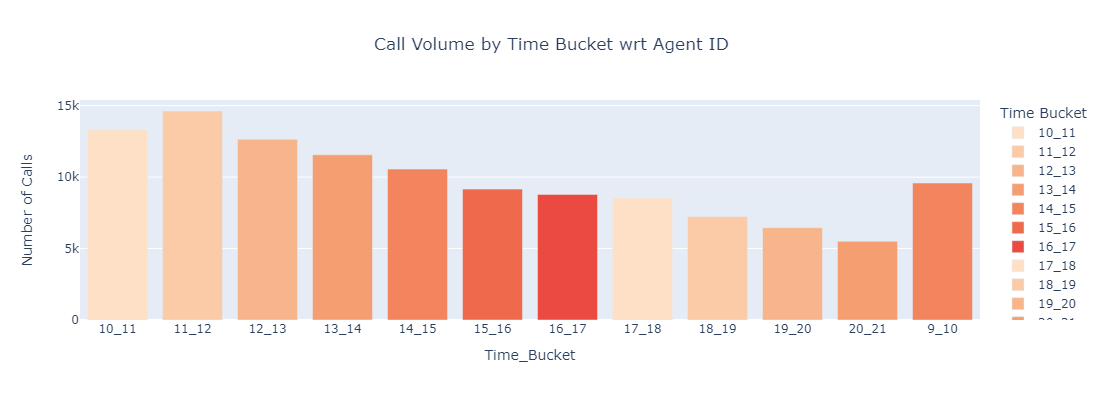

In [80]:
# Grouping by Time Bucket and counting the number of calls
call_volume = df_cleaned.groupby('Time_Bucket')['Agent_ID'].count().reset_index()

# Creating a bar chart
fig4 = px.bar(call_volume, x='Time_Bucket', y='Agent_ID', 
             title='Call Volume by Time Bucket wrt Agent ID',
             labels={'Agent_ID': 'Number of Calls'},
             color='Time_Bucket',
             color_discrete_sequence=px.colors.sequential.Peach)

fig4.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket")
)
fig4.show()

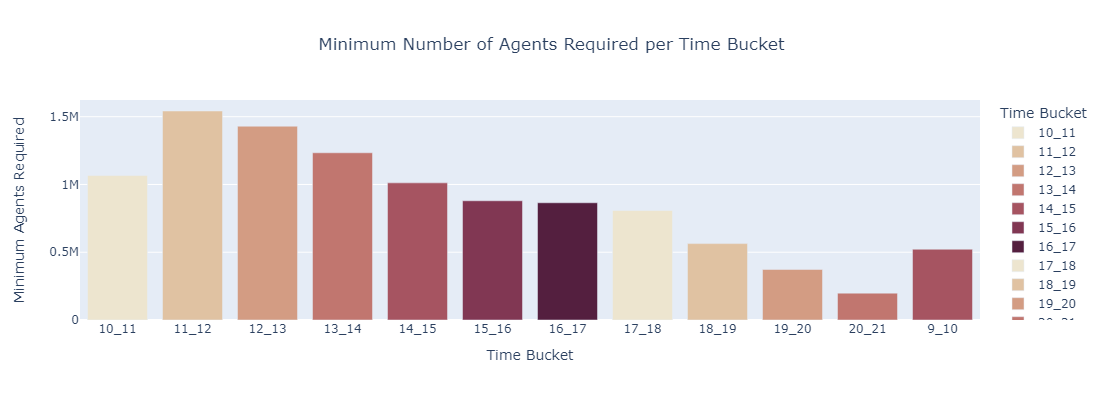

In [81]:
#3. Manpower Planning

# Assumption: Each agent handles 60% of 7.5 hours per day
agent_working_seconds = 0.6 * 7.5 * 3600

# Current abandon rate and target abandon rate
current_abandon_rate = 0.3
target_abandon_rate = 0.1

# Required calls answered to achieve target abandon rate
required_calls_answered = df_cleaned.groupby('Time_Bucket')['Agent_Name'].count() * (1 - target_abandon_rate)

# Calculate minimum number of agents required per time bucket
df_cleaned['Total_Call_Seconds'] = df_cleaned.groupby('Time_Bucket')['Call_Seconds(secs)'].transform('sum')
min_agents_required = (df_cleaned.groupby('Time_Bucket')['Total_Call_Seconds'].sum() / agent_working_seconds).reset_index()
min_agents_required.rename(columns={'Total_Call_Seconds': 'Min Agents Required'}, inplace=True)

# Visualize the manpower planning
fig5 = px.bar(min_agents_required, x='Time_Bucket', y='Min Agents Required',
             labels={'Min Agents Required': 'Minimum Agents Required', 'Time_Bucket': 'Time Bucket'},
             title='Minimum Number of Agents Required per Time Bucket',
             color = 'Time_Bucket',
            color_discrete_sequence=px.colors.sequential.Brwnyl)

fig5.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket")
)
fig5.show()

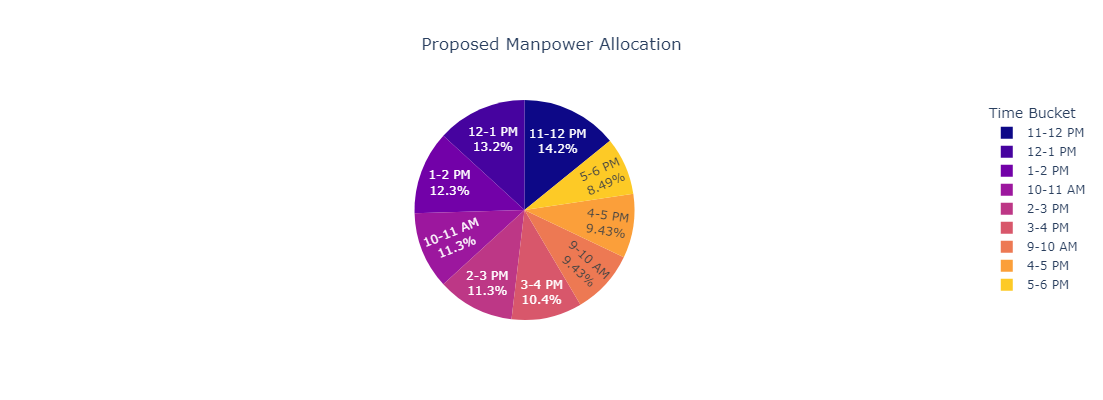

In [82]:
# Example Manpower Allocation (Dummy Data)
manpower_allocation = {
    'Time_Bucket': ['9-10 AM', '10-11 AM', '11-12 PM', '12-1 PM', '1-2 PM', '2-3 PM', '3-4 PM', '4-5 PM', '5-6 PM'],
    'Agents_Required': [10, 12, 15, 14, 13, 12, 11, 10, 9]
}
df_manpower = pd.DataFrame(manpower_allocation)

# Creating a pie chart
fig6 = px.pie(df_manpower, values='Agents_Required', names='Time_Bucket', 
             title='Proposed Manpower Allocation',
             color_discrete_sequence=px.colors.sequential.Plasma)
fig6.update_traces(textinfo='percent+label')
fig6.update_layout(
    width=400,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket"))
fig6.show()


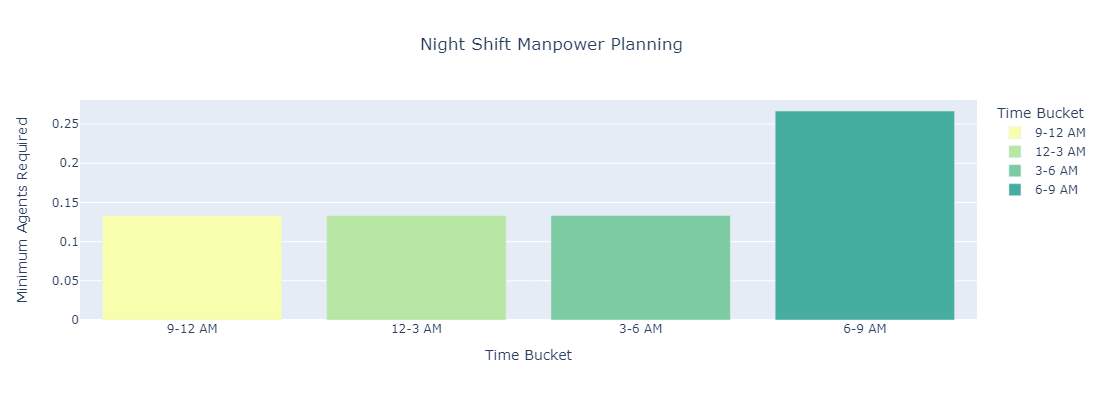

In [83]:
#4. Night Shift Manpower Planning

# Distribution of 30 calls at night
night_call_distribution = {'9-12 AM': 0.2, '12-3 AM': 0.2, '3-6 AM': 0.2, '6-9 AM': 0.4}
night_calls = 30

# Calculate the number of agents required for night shift
night_agents_required = {bucket: (night_call_distribution[bucket] * night_calls * target_abandon_rate) / (agent_working_seconds/3600) for bucket in night_call_distribution}

# Visualize the night shift manpower plan
night_agents_df = pd.DataFrame(list(night_agents_required.items()), columns=['Time Bucket', 'Min Agents Required'])
fig7 = px.bar(night_agents_df, x='Time Bucket', y='Min Agents Required',
             labels={'Min Agents Required': 'Minimum Agents Required', 'Time Bucket': 'Time Bucket'},
             title='Night Shift Manpower Planning',
            color = 'Time Bucket',
            color_discrete_sequence=px.colors.sequential.Bluyl)

fig7.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket")
)
fig7.show()


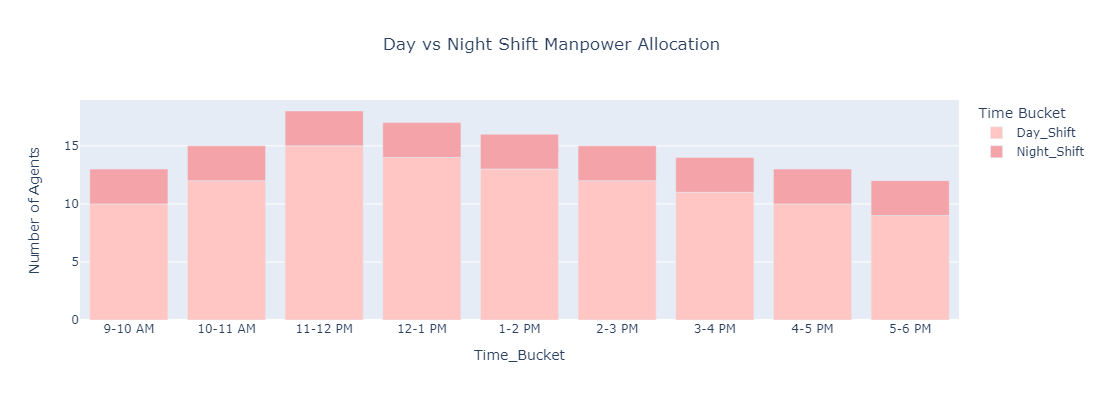

In [84]:
# Example data for day and night shift manpower allocation
shift_allocation = {
    'Time_Bucket': ['9-10 AM', '10-11 AM', '11-12 PM', '12-1 PM', '1-2 PM', '2-3 PM', '3-4 PM', '4-5 PM', '5-6 PM'],
    'Day_Shift': [10, 12, 15, 14, 13, 12, 11, 10, 9],
    'Night_Shift': [3, 3, 3, 3, 3, 3, 3, 3, 3]
}
df_shift = pd.DataFrame(shift_allocation)

# Creating a stacked bar chart
fig8 = px.bar(df_shift, x='Time_Bucket', y=['Day_Shift', 'Night_Shift'],
             title='Day vs Night Shift Manpower Allocation',
             labels={'value': 'Number of Agents'},
             color_discrete_sequence=px.colors.sequential.Burg)

fig8.update_layout(
    width=800,  # Adjust the width here
    height=400,  # You can also adjust the height if needed
    title=dict(x=0.5),  # Centering the title
    legend=dict(title="Time Bucket"))
fig8.show()


In [85]:
with open('Plotly_plots.html', 'a') as f: #Save plotly graphs in html format
    f.write(fig1.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig2.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig3.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig4.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig5.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig6.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig7.to_html(full_html = False, include_plotlyjs='cdn'))
    f.write(fig8.to_html(full_html = False, include_plotlyjs='cdn'))